In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Tamaños del mensaje
n = np.array([
    1,2,4,8,16,32,64,128,256,512,
    1024,2048,4096,8192,16384,
    32768,65536,131072,262144,
    524288,1048576
], dtype=float)

# Tiempos obtenidos en consola
time_sec = np.array([
    0.000000,0.000000,0.000000,0.000000,0.000000,
    0.000000,0.000000,0.000000,0.000000,0.000001,
    0.000001,0.000001,0.000002,0.000007,0.000012,
    0.000012,0.000023,0.000046,0.000094,
    0.000164,0.000318
], dtype=float)

In [2]:
coef = np.polyfit(n, time_sec, 1)

beta = coef[0]   # pendiente
alpha = coef[1]  # intercepto

print("Modelo obtenido:")
print(f"T(n) = {alpha:.6e} + {beta:.6e} · n")

Modelo obtenido:
T(n) = 1.890357e-06 + 3.057970e-10 · n


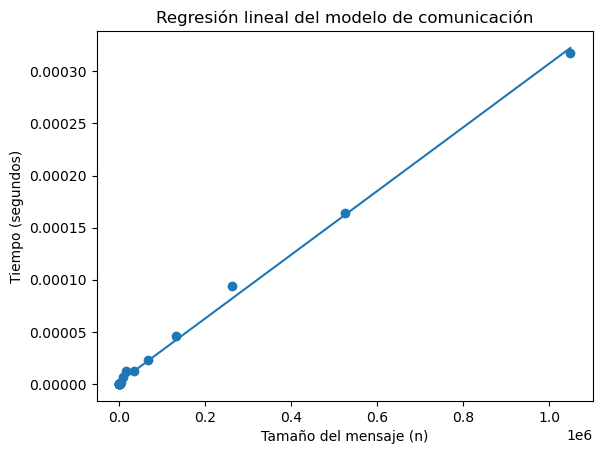

In [4]:
# Generamos valores para dibujar la recta
n_fit = np.linspace(min(n), max(n), 500)
t_fit = alpha + beta * n_fit

plt.figure()
plt.scatter(n, time_sec)   # puntos experimentales
plt.plot(n_fit, t_fit)     # recta de ajuste
plt.xlabel("Tamaño del mensaje (n)")
plt.ylabel("Tiempo (segundos)")
plt.title("Regresión lineal del modelo de comunicación")
plt.show()

In [6]:
mask = n >= 8192   # solo mensajes grandes
coef = np.polyfit(n[mask], time_sec[mask], 1)

beta = coef[0]
alpha = coef[1]

print("Modelo mejorado:")
print(f"T(n) = {alpha:.6e} + {beta:.6e} · n")

Modelo mejorado:
T(n) = 6.282727e-06 + 2.995453e-10 · n


In [7]:
# Cálculo del coeficiente de determinacion
from sklearn.metrics import r2_score

t_pred = alpha + beta * n[mask]
r2 = r2_score(time_sec[mask], t_pred)

print("R² =", r2)

R² = 0.9985518376854194
